In [ ]:
# Install the necessary library
!pip install -U sentence-transformers

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer, util

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
sentences = [
    # Topic: Cricket
    "The batsman hit a magnificent six over the long-on boundary.",
    "Fast bowlers often use the new ball to find swing and seam movement.",
    "The umpire raised his finger to signal a leg-before-wicket dismissal.",
    "Cricket is a sport played with a bat, ball, and eleven players per side.",
    # Topic: Cooking
    "Slowly simmer the tomato sauce until it reaches a thick consistency.",
    "A pinch of saffron can drastically enhance the aroma of the biryani.",
    "Whisk the egg whites until they form stiff peaks for the souffle.",
    # Topic: Cybersecurity
    "Multi-factor authentication adds a crucial layer of security to accounts.",
    "The firewall blocked a suspicious injection attack from an unknown IP.",
    "Phishing emails often mimic official banks to steal user credentials."
]

In [ ]:
embeddings = model.encode(sentences, convert_to_tensor=True)

In [ ]:
cosine_scores = util.cos_sim(embeddings, embeddings).cpu().numpy()

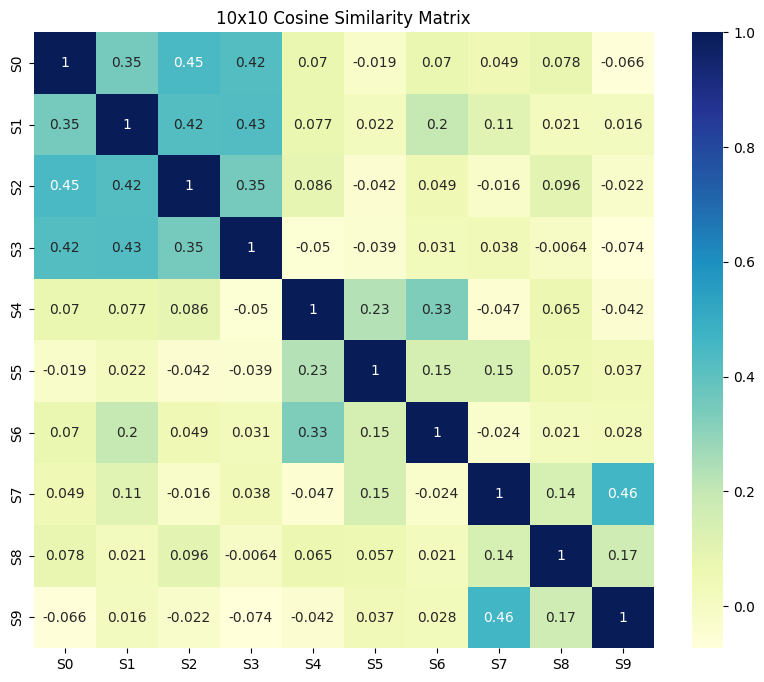

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(cosine_scores, annot=True, cmap='YlGnBu',
            xticklabels=[f"S{i}" for i in range(10)],
            yticklabels=[f"S{i}" for i in range(10)])
plt.title("10x10 Cosine Similarity Matrix")
plt.show()

In [ ]:
query = "The bowler took three wickets in one over"
query_embedding = model.encode(query, convert_to_tensor=True)

In [ ]:
hits = util.semantic_search(query_embedding, embeddings, top_k=2)[0]

In [ ]:
print(f"\nQuery: '{query}'")
print("-" * 30)
print("Top 2 most similar sentences:")


Query: 'The bowler took three wickets in one over'
------------------------------
Top 2 most similar sentences:


In [ ]:
for hit in hits:
    idx = hit['corpus_id']
    score = hit['score']
    print(f"Score: {score:.4f} | Sentence: {sentences[idx]}")

Score: 0.5387 | Sentence: The batsman hit a magnificent six over the long-on boundary.
Score: 0.4613 | Sentence: Fast bowlers often use the new ball to find swing and seam movement.
